
**How would we execute a query like this?**
``` sql
SELECT * 
FROM persons JOIN books
     ON name = author
WHERE price < 10
```




**Create some fake data**

In [1]:
from system.data_classes import *
from faker import Faker

Faker.seed(42)
fake = Faker()

number_of_tuples = 10000

# create some fake data mimicking tuples in a relation
persons = [Person(fake.name(), fake.date()) for _ in range(number_of_tuples)]
books = [
    Book(
        fake.sentence(),
        persons[i % number_of_tuples].name,
        fake.pyfloat(min_value=0, max_value=100, right_digits=2),
    )
    for i in range(number_of_tuples)
]
persons[:10], books[:10]

([Person(name='Allison Hill', birthday='1982-04-02'),
  Person(name='Megan Mcclain', birthday='1974-10-09'),
  Person(name='Allen Robinson', birthday='1997-09-26'),
  Person(name='Cristian Santos', birthday='1999-11-28'),
  Person(name='Kevin Pacheco', birthday='1970-05-11'),
  Person(name='Melissa Peterson', birthday='1978-07-14'),
  Person(name='Gabrielle Davis', birthday='1975-04-23'),
  Person(name='Lindsey Roman', birthday='2010-01-18'),
  Person(name='Valerie Gray', birthday='2000-04-18'),
  Person(name='Lisa Hensley', birthday='2001-09-08')],
 [Book(title='Prepare practice indeed computer phone rather.', author='Allison Hill', price=49.78),
  Book(title='Available Democrat collection more pass.', author='Megan Mcclain', price=86.0),
  Book(title='Threat service million himself all attention this.', author='Allen Robinson', price=0.58),
  Book(title='Executive season trial daughter.', author='Cristian Santos', price=51.3),
  Book(title='Sister including ahead practice word.', aut

**Emulate store**

In [2]:
import pickle

# write data into file to emulate store
with open("persons.pkl", "wb") as f:
    pickle.dump(
        [vars(person) for person in persons], f
    )  # convert into dictionary (aka Tuple type)
with open("books.pkl", "wb") as f:
    pickle.dump(
        [vars(book) for book in books], f
    )  # convert into dictionary (aka Tuple type)

**Create QEP**

In [3]:
from system.query_processing.operators import *

scan_persons = Scan("persons.pkl")
scan_books = Scan("books.pkl")
filter_books = Filter(scan_books, "price < 10")
join = SHJ(scan_persons, filter_books, "name", "author")
query_plan = Print(join)

query_plan.dump()

Print
  SHJ on `name=author`
    Scan(persons.pkl)
    Filter on `price < 10`
      Scan(books.pkl)


**Interpret QEP**

In [4]:
query_plan.interpret_open()

('Threat service million himself all attention this.', 'Allen Robinson', 0.58, 'Allen Robinson', '1997-09-26')
('Help build each these guy.', 'Arthur James', 9.93, 'Arthur James', '2024-09-01')
('Very visit front ask fast oil great whatever.', 'David Caldwell', 6.6, 'David Caldwell', '1981-10-04')
('Alone government machine will service give religious.', 'Dr. Angel Lewis MD', 3.55, 'Dr. Angel Lewis MD', '2021-03-21')
('Use soldier individual figure total wrong.', 'Richard Henson', 8.83, 'Richard Henson', '1992-04-20')
('Pm affect nation positive thousand environmental nature.', 'Rita Keith', 5.15, 'Rita Keith', '1971-05-12')
('Player special sit billion.', 'Larry Dixon', 9.46, 'Larry Dixon', '1991-02-21')
('However as anything draw mean.', 'Kimberly Ball', 9.92, 'Kimberly Ball', '2010-09-20')
('Discuss appear reason marriage.', 'John Santana', 3.8, 'John Santana', '2013-09-08')
('Evidence make yet everybody worker support no.', 'Bradley Robertson', 0.32, 'Bradley Robertson', '2004-09-2

**Compile QEP**

In [5]:
code = query_plan.compile()
print(code)

import pickle

ht = dict()
with open('persons.pkl', 'rb') as f:
    for tup in pickle.load(f):
        ht.setdefault(tup['name'], list()).append(tup)
with open('books.pkl', 'rb') as f:
    for tup in pickle.load(f):
        if tup['price'] < 10:
            for tup2 in ht.get(tup['author'], list()):
                tup = tup | tup2
                print(tuple(tup.values()))


**Compile generated Python code to byte code and run executable**

In [6]:
from py_compile import compile
import subprocess

# write generated code into file
with open("codegen.py", "w") as f:
    f.write(code)

# create executable file
with open("codegen.pyc", "w"):
    pass

# compile Python code to byte code
compile("codegen.py", "codegen.pyc", doraise=True)
# run executable
subprocess.call(["python3", "codegen.pyc"])

('Threat service million himself all attention this.', 'Allen Robinson', 0.58, 'Allen Robinson', '1997-09-26')
('Help build each these guy.', 'Arthur James', 9.93, 'Arthur James', '2024-09-01')
('Very visit front ask fast oil great whatever.', 'David Caldwell', 6.6, 'David Caldwell', '1981-10-04')
('Alone government machine will service give religious.', 'Dr. Angel Lewis MD', 3.55, 'Dr. Angel Lewis MD', '2021-03-21')
('Use soldier individual figure total wrong.', 'Richard Henson', 8.83, 'Richard Henson', '1992-04-20')
('Pm affect nation positive thousand environmental nature.', 'Rita Keith', 5.15, 'Rita Keith', '1971-05-12')
('Player special sit billion.', 'Larry Dixon', 9.46, 'Larry Dixon', '1991-02-21')
('However as anything draw mean.', 'Kimberly Ball', 9.92, 'Kimberly Ball', '2010-09-20')
('Discuss appear reason marriage.', 'John Santana', 3.8, 'John Santana', '2013-09-08')
('Evidence make yet everybody worker support no.', 'Bradley Robertson', 0.32, 'Bradley Robertson', '2004-09-2

0

**But how fast is each execution paradigm?**

In [7]:
from time import time_ns

num_runs = 5
scale_factors = [0.1, 0.25, 0.5, 0.75, 1]


def measure_interpreter(query_plan: Operator) -> list[int]:
    """
    Measures the running time in ms using the interpreter.
    :param query_plan: QEP to execute.
    :return: List of `num_runs` measurements.
    """

    res = list()
    for i in range(num_runs):
        interpret_start = time_ns()
        query_plan.interpret_open()
        interpret_end = time_ns()
        res.append((interpret_end - interpret_start) / 1000)
    return res


def measure_compiler(query_plan: Operator) -> list[int]:
    """
    Measures the running time in ms using the compiler.
    :param query_plan: QEP to execute.
    :return: List of `num_runs` measurements.
    """

    res = list()
    for i in range(num_runs):
        compile_start = time_ns()
        code = query_plan.compile()
        with open("codegen.py", "w") as f:
            f.write(code)
        with open("codegen.pyc", "w"):
            pass
        compile("codegen.py", "codegen.pyc", doraise=True)
        subprocess.call(["python3", "codegen.pyc"])
        compile_end = time_ns()
        res.append((compile_end - compile_start) / 1000)
    return res


def create_qep(sf: int):
    scan_persons = Scan("persons.pkl", number_of_tuples * sf)
    scan_books = Scan("books.pkl", number_of_tuples * sf)
    filter_books = Filter(scan_books, "price < 10")
    join = SHJ(scan_persons, filter_books, "name", "author")
    return Count(join)


data: list[tuple[str, int, int]] = list()
for sf in scale_factors:
    query_plan = create_qep(sf)
    for time in measure_interpreter(query_plan):
        data.append(("interpreter", sf, time))
    for time in measure_compiler(query_plan):
        data.append(("compiler", sf, time))

Text(0, 0.5, 'Running time (ms)')

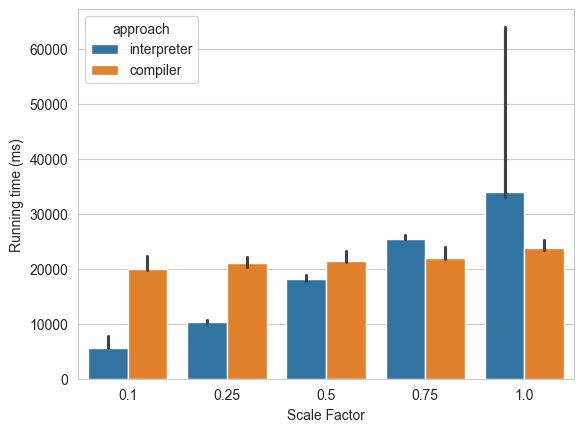

In [8]:
import numpy as np
import pandas as pd
import seaborn as sns

df = pd.DataFrame(data, columns=["approach", "scale_factor", "running_time"])
ax = sns.barplot(
    df, x="scale_factor", y="running_time", hue="approach", estimator=np.median
)
ax.set_xlabel("Scale Factor")
ax.set_ylabel("Running time (ms)")

In [9]:
!rm persons.pkl books.pkl codegen.py codegen.pyc